In [1]:
import matplotlib.pyplot as plt
import os
import numpy as np
import plotly.graph_objects as go
# from tqdm import tqdm
from network_funcs import *
from qopt_funcs import *
import networkx as nx
# import random
import time
import shutil    # to copy files at the end of the script

# DV and CV key rates

In [2]:
from qopt_funcs import *

func_CV = lambda dist : hybrid_keyrate_bitpersec(state_of_the_art_params, dist, d_hybrid = float('inf'))
# d_c_CV = bisection_solver(func_CV, 10E-06, d_max)            # not starting from 0 bc if T=1 there is a division by 0
func_DV = lambda dist : hybrid_keyrate_bitpersec(state_of_the_art_params, dist, d_hybrid = 0)
# d_c_DV = bisection_solver(func_DV, 10E-06, d_max)
diff = lambda d: func_CV(d) - func_DV(d)
d_cross = bisection_solver(diff, 10E-06, 1000)
d_cross

91.12686827681125

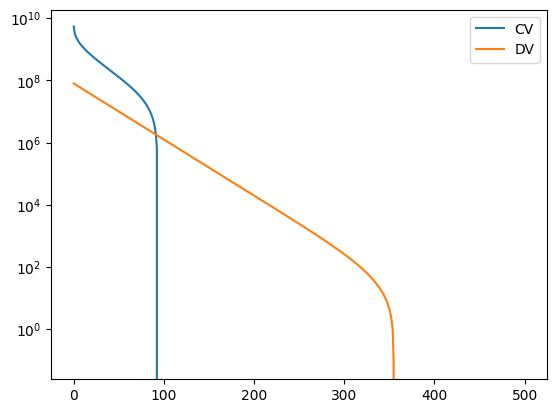

In [3]:
xs = np.linspace(0.01, 500, 500)
plt.plot(xs, [func_CV(x) for x in xs], label='CV')
plt.plot(xs, [func_DV(x) for x in xs], label='DV')
plt.legend()
plt.yscale('log')


# number of CV-pruned links suitable for DV-QKD

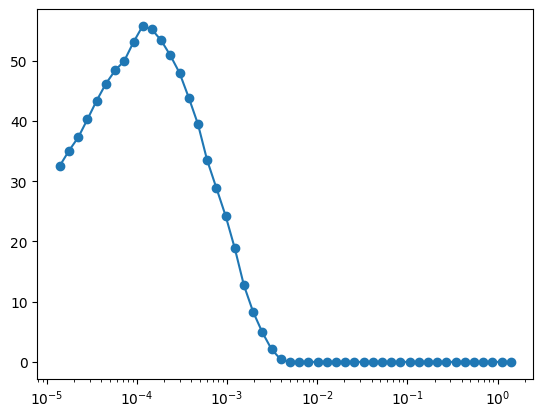

In [4]:
data = np.loadtxt("budget_outputs/N50/budg_N50_B0_centrality.dat")
plt.plot(data[0], data[1], marker='o')
plt.xscale('log')

# Connectivity vs $\rho$ for different DV budgets

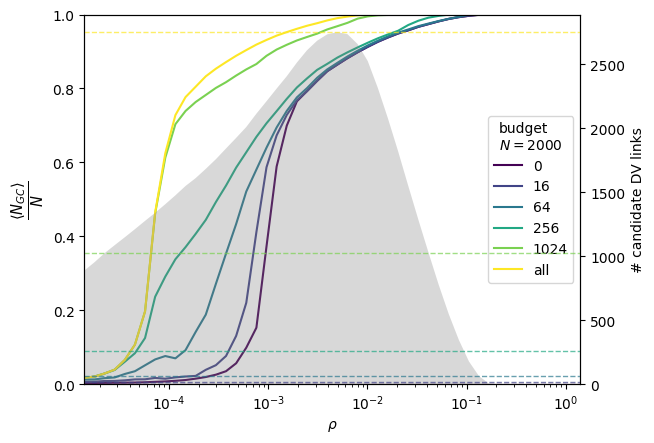

In [34]:
budget_list = [0, 16, 64, 256, 1024, np.inf]            # list of numbers of DV edges allowed in the system
N = 2000
criterion = 'centrality'


def budget_label(DV_budget):
    return 'Ball' if np.isinf(DV_budget) else f'B{int(DV_budget)}'


def budget_output_path(prefix, N, DV_budget, criterion):
    return f"budget_outputs/N{N}/{prefix}_N{N}_{budget_label(DV_budget)}_{criterion}.dat"

# Collect DV candidate data for averaging
# Use the centrality ranking, which is the default criterion for the connectivity plots.
dv_values_list = []
rhos = None
for budget in budget_list:
    num_DV_candidates = np.loadtxt(budget_output_path('budg', N, budget, criterion))
    if rhos is None:
        rhos = num_DV_candidates[0]
    dv_values_list.append(num_DV_candidates[1])

# Average the DV candidate values
avg_dv_candidates = np.mean(np.array(dv_values_list), axis=0)

# Plot
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

colors = plt.cm.viridis(np.linspace(0, 1, len(budget_list)))

for i, budget in enumerate(budget_list):
    conn = np.loadtxt(budget_output_path('conn', N, budget, criterion))
    label = 'all' if budget == np.inf else f'{budget}'
    ax1.plot(conn[0], conn[1], '-', color=colors[i], label=label)
    if budget != np.inf:
        ax2.axhline(y=budget, color=colors[i], linestyle='--', linewidth=1, alpha=0.7)
    else:
        ax2.axhline(y=np.max(avg_dv_candidates), color=colors[i], linestyle='--', linewidth=1, alpha=0.7)

# Plot averaged DV candidates as shaded area on ax2
ax2.fill_between(rhos, 0, avg_dv_candidates, alpha=0.3, color='gray', edgecolor='none')

ax1.legend(title=f'budget\n$N={N}$', loc='center right')
ax1.set_xscale('log')
ax1.set_xlim(np.min(rhos), np.max(rhos))
ax1.set_ylim(0.,1.0)
ax2.set_ylim(0., np.amax(avg_dv_candidates)*1.05)
ax1.set_xlabel(r'$\rho$')
ax1.set_ylabel(r'$\frac{\langle N_{GC} \rangle}{N}$', fontsize=15)
ax2.set_ylabel('# candidate DV links')
os.makedirs("budget_plots", exist_ok=True)
plt.savefig(os.path.join("budget_plots", f"budgeted_connectivity_vs_rho_N{N}.png"), dpi=300)

# Connectivity at $\frac{\rho_c^{(CV)}+\rho_c^{(DV)}}{2}$ as a function of the DV budget, for different ranking criteria

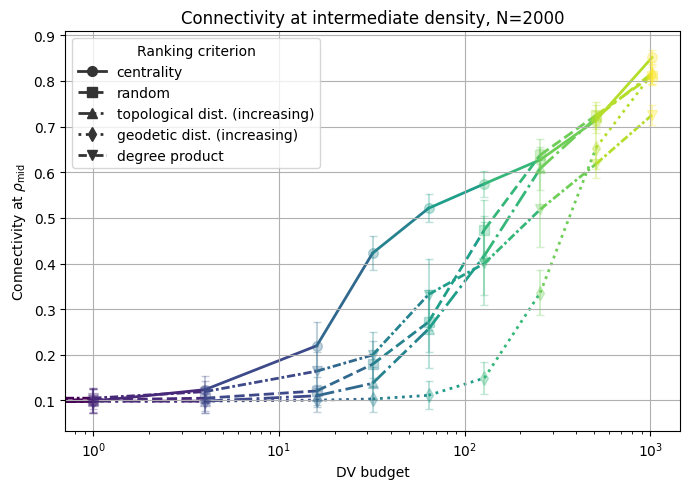

In [28]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Parametri
N = 2000
folder = f"budget_outputs/N{N}"
rankings = [
    ("centrality", "centrality"),
    ("random", "random"),
    ("topological_distance", "topological_distance"),
    ("geodetic_distance", "geodetic_distance"),
    ("degree", "degree")
]


def budget_label(DV_budget):
    return 'Ball' if np.isinf(DV_budget) else f'B{int(DV_budget)}'


def filename_for(prefix, N, DV_budget, criterion):
    return f"{prefix}_N{N}_{budget_label(DV_budget)}_{criterion}.dat"


def parse_budget_label(filename):
    parts = filename.replace('.dat', '').split('_')
    label = parts[2]
    return np.inf if label == 'Ball' else float(label[1:])


# Trova tutti i budget disponibili per ogni ranking
all_files = os.listdir(folder)
budget_set = set()
budget_files = {}
for criterion, rankname in rankings:
    files = [
        f for f in all_files
        if f.startswith(f"conn_N{N}_") and f.endswith(f"_{criterion}.dat")
    ]
    budgets = [parse_budget_label(f) for f in files]
    budget_files[rankname] = sorted(
        zip(budgets, files),
        key=lambda x: x[0] if np.isfinite(x[0]) else np.inf
    )
    budget_set.update(budgets)

# Funzione per leggere dati da file
def read_conn_file(path):
    with open(path, 'r') as f:
        lines = f.readlines()
    rhos = np.array([float(x) for x in lines[0].split()])
    conn = np.array([float(x) for x in lines[1].split()])
    err = np.array([float(x) for x in lines[2].split()])
    return rhos, conn, err

# Trova la densità critica CV e DV per ogni ranking
crit_rhos = {}
for criterion, rankname in rankings:
    # budget=0 → CV, budget=inf → DV
    file_cv = filename_for('conn', N, 0, criterion)
    file_dv = filename_for('conn', N, np.inf, criterion)
    if file_cv in all_files and file_dv in all_files:
        rhos_cv, conn_cv, _ = read_conn_file(os.path.join(folder, file_cv))
        rhos_dv, conn_dv, _ = read_conn_file(os.path.join(folder, file_dv))
        # Soglia: dove la connettività supera 0.5
        try:
            rho_cv = rhos_cv[np.where(conn_cv > 0.5)[0][0]]
        except IndexError:
            rho_cv = rhos_cv[-1]
        try:
            rho_dv = rhos_dv[np.where(conn_dv > 0.5)[0][0]]
        except IndexError:
            rho_dv = rhos_dv[-1]
        crit_rhos[rankname] = (rho_cv, rho_dv)

# Densità intermedia (media tra CV e DV per centrality)
if "centrality" in crit_rhos:
    rho_mid = 0.5 * (crit_rhos["centrality"][0] + crit_rhos["centrality"][1])
else:
    # fallback: media tra tutti i ranking disponibili
    rho_mid = np.mean([0.5*(v[0]+v[1]) for v in crit_rhos.values()])

# Estrai la connettività a rho_mid per ogni budget e ranking
plot_data = {}
for criterion, rankname in rankings:
    plot_data[rankname] = []
    for budg, fname in budget_files[rankname]:
        path = os.path.join(folder, fname)
        rhos, conn, err = read_conn_file(path)
        idx = np.abs(rhos - rho_mid).argmin()
        plot_data[rankname].append((budg, conn[idx], err[idx]))
    plot_data[rankname].sort(key=lambda x: x[0])

from matplotlib.lines import Line2D

# Plot
fig, ax = plt.subplots(figsize=(7, 5))

markers = {
    "centrality": "o",
    "random": "s",
    "topological_distance": "^",
    "geodetic_distance": "d",
    "degree": "v"
}

linestyles = {
    "centrality": "-",
    "random": "--",
    "topological_distance": "-.",
    "geodetic_distance": ":",
    "degree": (0, (3, 1, 1, 1))
}

legend_labels = {
    "centrality": "centrality",
    "random": "random",
    "topological_distance": "topological dist. (increasing)",
    "geodetic_distance": "geodetic dist. (increasing)",
    "degree": "degree product"
}

# Lista ordinata dei budget finiti, per costruire la colormap
budget_list = sorted([float(b) for b in budget_set if np.isfinite(b)])

colors = plt.cm.viridis(np.linspace(0, 1, len(budget_list)))
color_by_budget = dict(zip(budget_list, colors))

legend_handles = []

for rankname, data in plot_data.items():
    data_finite = [x for x in data if np.isfinite(x[0])]

    budgets = np.array([x[0] for x in data_finite])
    conns = np.array([x[1] for x in data_finite])
    errs = np.array([x[2] for x in data_finite])

    marker = markers.get(rankname, "o")
    linestyle = linestyles.get(rankname, "-")

    # Linea colorata segmento per segmento.
    # Il colore del segmento è preso dal budget iniziale del segmento.
    for j in range(len(budgets) - 1):
        b0, b1 = budgets[j], budgets[j + 1]
        c0, c1 = conns[j], conns[j + 1]

        ax.plot(
            [b0, b1],
            [c0, c1],
            linestyle=linestyle,
            color=color_by_budget[b0],
            alpha=1.0,
            linewidth=2,
            zorder=1
        )

    # Punti + errorbar colorati secondo il budget
    for b, c, e in zip(budgets, conns, errs):
        col = color_by_budget[b]

        ax.errorbar(
            b,
            c,
            yerr=e,
            color=col,
            ecolor=col,
            marker=marker,
            linestyle="none",
            markersize=7,
            capsize=3,
            alpha=0.3,
            zorder=2
        )

    # Handle manuale per la legenda: mostra marker + linestyle
    legend_handles.append(
        Line2D(
            [0],
            [0],
            color="0.2",
            marker=marker,
            linestyle=linestyle,
            linewidth=2,
            markersize=7,
            label=legend_labels.get(rankname, rankname)
        )
    )

ax.set_xscale("log")
ax.set_xlabel("DV budget")
ax.set_ylabel(r"Connectivity at $\rho_{\mathrm{mid}}$")

ax.legend(
    handles=legend_handles,
    title="Ranking criterion"
)

plt.title(f"Connectivity at intermediate density, N={N}")
plt.tight_layout()
plt.grid()
os.makedirs("budget_plots", exist_ok=True)
plt.savefig(os.path.join("budget_plots", f"connectivity_vs_budget_N{N}.png"), dpi=300)
plt.show()

# Critical density ($C(\rho_c)=0.5$) as a function of the budget, for different ranking criteria

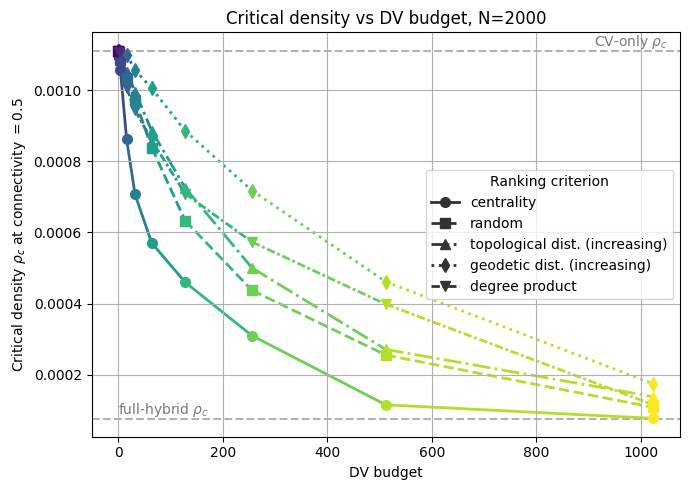

In [29]:
def critical_rho(rhos, conn, threshold=0.5):
    above = np.where(conn >= threshold)[0]

    if len(above) == 0:
        return np.nan

    i = above[0]

    # Se già il primo punto è sopra soglia
    if i == 0:
        return rhos[0]

    # Interpolazione lineare tra i-1 e i
    x0, x1 = rhos[i - 1], rhos[i]
    y0, y1 = conn[i - 1], conn[i]

    if y1 == y0:
        return x1

    return x0 + (threshold - y0) * (x1 - x0) / (y1 - y0)


crit_plot_data = {}

for criterion, rankname in rankings:
    crit_plot_data[rankname] = []

    for budg, fname in budget_files[rankname]:
        path = os.path.join(folder, fname)
        rhos, conn, err = read_conn_file(path)

        rho_c = critical_rho(rhos, conn, threshold=0.5)

        budget_value = float(budg) if np.isfinite(budg) else np.inf
        crit_plot_data[rankname].append((budget_value, rho_c))

    crit_plot_data[rankname].sort(key=lambda x: x[0])


from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(7, 5))

markers = {
    "centrality": "o",
    "random": "s",
    "topological_distance": "^",
    "geodetic_distance": "d",
    "degree": "v"
}

linestyles = {
    "centrality": "-",
    "random": "--",
    "topological_distance": "-.",
    "geodetic_distance": ":",
    "degree": (0, (3, 1, 1, 1))
}

legend_labels = {
    "centrality": "centrality",
    "random": "random",
    "topological_distance": "topological dist. (increasing)",
    "geodetic_distance": "geodetic dist. (increasing)",
    "degree": "degree product"
}

budget_list = sorted([float(b) for b in budget_set if np.isfinite(b)])
colors = plt.cm.viridis(np.linspace(0, 1, len(budget_list)))
color_by_budget = dict(zip(budget_list, colors))

legend_handles = []

for rankname, data in crit_plot_data.items():
    data_finite = [
        x for x in data
        if np.isfinite(x[0]) and np.isfinite(x[1])
    ]

    budgets = np.array([x[0] for x in data_finite])
    rho_crits = np.array([x[1] for x in data_finite])

    marker = markers.get(rankname, "o")
    linestyle = linestyles.get(rankname, "-")

    # Linea colorata segmento per segmento
    for j in range(len(budgets) - 1):
        b0, b1 = budgets[j], budgets[j + 1]
        r0, r1 = rho_crits[j], rho_crits[j + 1]

        ax.plot(
            [b0, b1],
            [r0, r1],
            linestyle=linestyle,
            color=color_by_budget[b0],
            linewidth=2,
            alpha=1.0,
            zorder=1
        )

    # Marker colorati secondo il budget
    for b, rho_c in zip(budgets, rho_crits):
        ax.plot(
            b,
            rho_c,
            marker=marker,
            color=color_by_budget[b],
            linestyle="none",
            markersize=7,
            zorder=2
        )

    legend_handles.append(
        Line2D(
            [0],
            [0],
            color="0.2",
            marker=marker,
            linestyle=linestyle,
            linewidth=2,
            markersize=7,
            label=legend_labels.get(rankname, rankname)
        )
    )


# Linee orizzontali di riferimento:
# budget=0 -> CV-only
# budget=inf -> full hybrid
ref_rank = "centrality"

rho_cv_only = None
rho_full_hybrid = None

if ref_rank in crit_plot_data:
    for budget_value, rho_c in crit_plot_data[ref_rank]:
        if budget_value == 0 and np.isfinite(rho_c):
            rho_cv_only = rho_c
        elif np.isinf(budget_value) and np.isfinite(rho_c):
            rho_full_hybrid = rho_c

if rho_cv_only is not None:
    ax.axhline(
        rho_cv_only,
        color="0.4",
        linestyle="--",
        linewidth=1.5,
        alpha=0.5,
        zorder=0
    )

    ax.text(
        0.98,
        rho_cv_only,
        r"CV-only $\rho_c$",
        transform=ax.get_yaxis_transform(),
        ha="right",
        va="bottom",
        color="0.35",
        fontsize=10,
        alpha=0.8
    )

if rho_full_hybrid is not None:
    ax.axhline(
        rho_full_hybrid,
        color="0.4",
        linestyle="--",
        linewidth=1.5,
        alpha=0.5,
        zorder=0
    )

    ax.text(
        0.2,
        rho_full_hybrid,
        r"full-hybrid $\rho_c$",
        transform=ax.get_yaxis_transform(),
        ha="right",
        va="bottom",
        color="0.35",
        fontsize=10,
        alpha=0.8
    )

# ax.set_xscale("log")
ax.set_xlabel("DV budget")
ax.set_ylabel(r"Critical density $\rho_c$ at connectivity $= 0.5$")

ax.legend(
    handles=legend_handles,
    title="Ranking criterion"
)

plt.title(f"Critical density vs DV budget, N={N}")
plt.tight_layout()
plt.grid()
os.makedirs("budget_plots", exist_ok=True)
plt.savefig(os.path.join("budget_plots", f"critical_density_vs_budget_N{N}.png"), dpi=300)
plt.show()

# topological distance vs $N$, different budgets 

Saved c:\Users\lmariani\My_Programs\github\qkd_networks\topological_distance_vs_N_by_budget.png


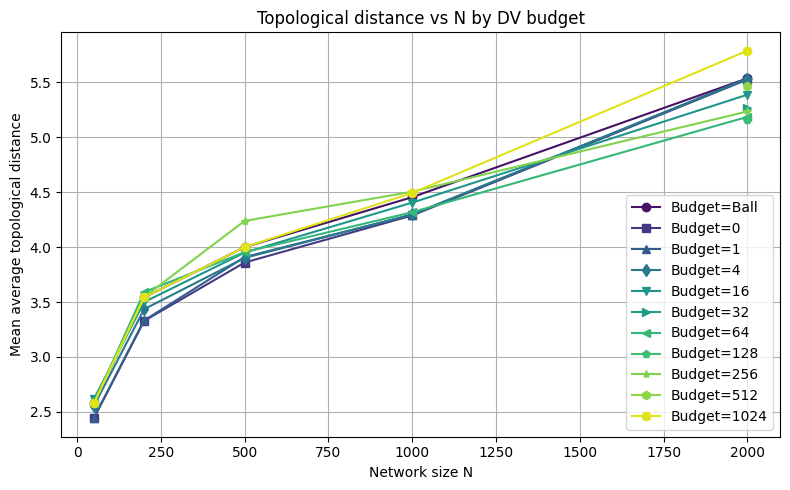

In [18]:
# Plot mean average topological distance vs N for each DV budget
import os, glob
import numpy as np
import matplotlib.pyplot as plt

base = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
outputs_dir = os.path.join(os.getcwd(), 'budget_outputs')

pattern = os.path.join(outputs_dir, 'N*', 'topd_N*_B*_topological_distance.dat')
files = sorted(glob.glob(pattern))

if len(files) == 0:
    print('No topd files found under', outputs_dir)
else:
    data_by_budget = {}

    for f in files:
        fname = os.path.basename(f)
        folder = os.path.basename(os.path.dirname(f))

        try:
            N = int(folder.replace('N', ''))
        except Exception:
            parts = fname.split('_')
            N = int(parts[1][1:])

        parts = fname.split('_')
        budg_token = None
        for p in parts:
            if p.startswith('B'):
                budg_token = p
                break
        if budg_token is None:
            continue

        if budg_token == 'Ball':
            budg_label = 'Ball'
            budget_value = np.inf
        else:
            try:
                budget_value = int(budg_token[1:])
                budg_label = str(budget_value)
            except Exception:
                budget_value = budg_token
                budg_label = budg_token

        try:
            arr = np.loadtxt(f)
        except Exception as e:
            print('Failed to load', f, e)
            continue

        if arr.ndim == 1:
            avg_topd = arr[1] if arr.size >= 2 else np.nan
        else:
            avg_topd = np.mean(arr[1, :]) if arr.shape[0] >= 2 else np.nan

        data_by_budget.setdefault(budg_label, []).append((N, float(avg_topd), budget_value))

    plt.figure(figsize=(8, 5))
    markers = ['o', 's', '^', 'd', 'v', '>', '<', 'p', '*', 'h']

    # Use the same viridis palette as the other budget plots.
    budget_values = sorted(
        [x[2] for x in sum(data_by_budget.values(), []) if np.isfinite(x[2])],
        key=lambda b: b
    )
    budget_values = [np.inf] + budget_values if np.inf not in budget_values else budget_values
    colors = plt.cm.viridis(np.linspace(0.05, 0.95, len(budget_values)))
    color_by_budget = dict(zip(budget_values, colors))

    for i, (budg_label, pairs) in enumerate(sorted(data_by_budget.items(), key=lambda x: (x[0] != 'Ball', float('inf') if x[0] == 'Ball' else float(x[0])))):
        pairs_sorted = sorted(pairs, key=lambda x: x[0])
        Ns = [p[0] for p in pairs_sorted]
        vals = [p[1] for p in pairs_sorted]
        if len(Ns) == 0:
            continue

        budget_value = pairs_sorted[0][2]
        color = color_by_budget.get(budget_value, plt.cm.viridis(0.8))
        marker = markers[i % len(markers)]

        plt.plot(Ns, vals, marker=marker, linestyle='-', color=color, label=f'Budget={budg_label}')

    plt.xlabel('Network size N')
    plt.ylabel('Mean average topological distance')
    plt.title('Topological distance vs N by DV budget')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    os.makedirs('budget_plots', exist_ok=True)
    out_png = os.path.join(os.getcwd(), 'budget_plots', 'topological_distance_vs_N_by_budget.png')
    plt.savefig(out_png, dpi=300)
    print('Saved', out_png)
    plt.show()

# Fiedler value vs budget

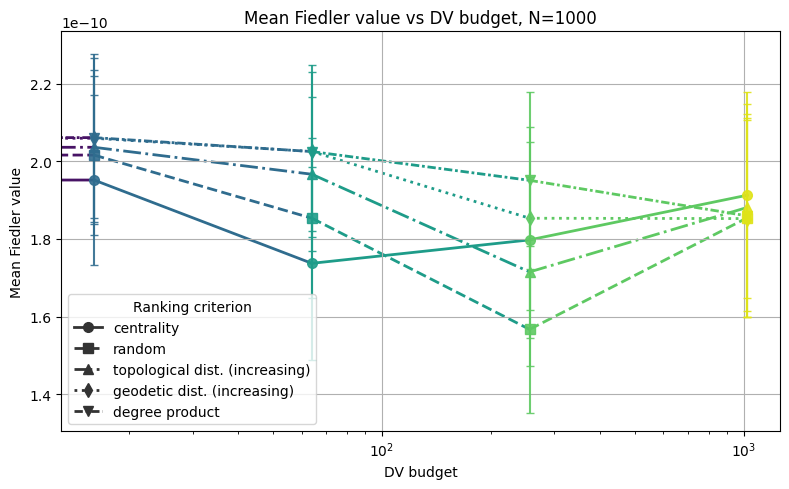

In [26]:
# Mean Fiedler value vs DV budget for different ranking criteria
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

N = 1000
folder = os.path.join("budget_outputs", f"N{N}")

markers = {
    "centrality": "o",
    "random": "s",
    "topological_distance": "^",
    "geodetic_distance": "d",
    "degree": "v"
}

linestyles = {
    "centrality": "-",
    "random": "--",
    "topological_distance": "-.",
    "geodetic_distance": ":",
    "degree": (0, (3, 1, 1, 1))
}

legend_labels = {
    "centrality": "centrality",
    "random": "random",
    "topological_distance": "topological dist. (increasing)",
    "geodetic_distance": "geodetic dist. (increasing)",
    "degree": "degree product"
}

budget_list = sorted([float(b) for b in budget_set if np.isfinite(b)])
colors = plt.cm.viridis(np.linspace(0.05, 0.95, len(budget_list)))
color_by_budget = dict(zip(budget_list, colors))

fig, ax = plt.subplots(figsize=(8, 5))
legend_handles = []

for criterion, rankname in rankings:
    series = []
    for budg, _ in budget_files[rankname]:
        path = os.path.join(folder, filename_for('fiedler', N, budg, criterion))
        if not os.path.exists(path):
            continue

        data = np.loadtxt(path)
        if data.ndim == 1:
            y = float(data[1]) if data.size >= 2 else np.nan
            yerr = float(data[2]) if data.size >= 3 else 0.0
        else:
            y = float(np.mean(data[1])) if data.shape[0] >= 2 else np.nan
            yerr = float(np.mean(data[2])) if data.shape[0] >= 3 else 0.0

        series.append((float(budg) if np.isfinite(budg) else np.inf, y, yerr))

    series = sorted(series, key=lambda x: x[0])
    if not series:
        continue

    budgets = np.array([x[0] for x in series])
    values = np.array([x[1] for x in series])

    marker = markers.get(rankname, 'o')
    linestyle = linestyles.get(rankname, '-')

    for j in range(len(budgets) - 1):
        b0, b1 = budgets[j], budgets[j + 1]
        y0, y1 = values[j], values[j + 1]
        ax.plot([b0, b1], [y0, y1], linestyle=linestyle, color=color_by_budget[b0], linewidth=2, alpha=1.0, zorder=1)

    for b, y, e in series:
        ax.errorbar(
            b, y, yerr=e,
            fmt=marker,
            color=color_by_budget[b] if np.isfinite(b) else color_by_budget[max(budget_list)],
            ecolor=color_by_budget[b] if np.isfinite(b) else color_by_budget[max(budget_list)],
            linestyle='none',
            markersize=7,
            capsize=3,
            alpha=0.9,
            zorder=2
        )

    legend_handles.append(
        Line2D([0], [0], color='0.2', marker=marker, linestyle=linestyle, linewidth=2, markersize=7,
               label=legend_labels.get(rankname, rankname))
    )

ax.set_xscale('log')
ax.set_xlabel('DV budget')
ax.set_ylabel('Mean Fiedler value')
ax.legend(handles=legend_handles, title='Ranking criterion')
ax.grid(True)
plt.title(f'Mean Fiedler value vs DV budget, N={N}')
plt.tight_layout()
os.makedirs('budget_plots', exist_ok=True)
plt.savefig(os.path.join('budget_plots', f'fiedler_vs_budget_N{N}.png'), dpi=300)
plt.show()

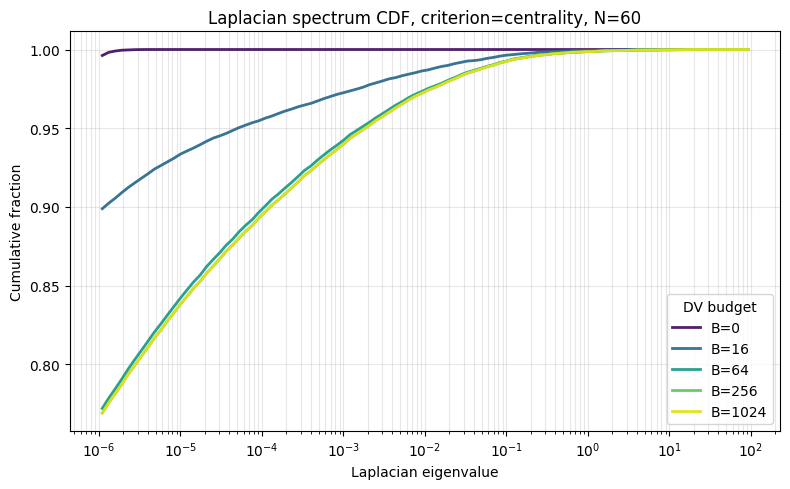

In [37]:
# Laplacian spectrum CDF for the centrality criterion
import os
import numpy as np
import matplotlib.pyplot as plt

N = 60  # use the available lapcdf outputs in budget_outputs/N60
criterion = 'centrality'
folder = os.path.join('budget_outputs', f'N{N}')

budget_values = sorted([float(b) for b in budget_set if np.isfinite(b)])
colors = plt.cm.viridis(np.linspace(0.05, 0.95, len(budget_values)))
color_by_budget = dict(zip(budget_values, colors))

bin_edges = np.logspace(-6, 2, num=101)
x = (bin_edges[:-1] + bin_edges[1:]) / 2.0

fig, ax = plt.subplots(figsize=(8, 5))

for budget_value in budget_values:
    path = os.path.join(folder, filename_for('lapcdf', N, budget_value, criterion))
    if not os.path.exists(path):
        continue

    data = np.loadtxt(path, ndmin=2)
    if data.shape[0] < 2:
        continue

    y = np.nanmean(data[1:], axis=1)
    ax.plot(
        x,
        y,
        label=f'B={int(budget_value)}',
        color=color_by_budget[budget_value],
        linewidth=2,
        alpha=0.95,
    )

ax.set_xscale('log')
ax.set_xlabel('Laplacian eigenvalue')
ax.set_ylabel('Cumulative fraction')
ax.set_title(f'Laplacian spectrum CDF, criterion={criterion}, N={N}')
ax.legend(title='DV budget')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
os.makedirs('budget_plots', exist_ok=True)
plt.savefig(os.path.join('budget_plots', f'lapcdf_centrality_N{N}.png'), dpi=300)
plt.show()